In [18]:
!pip3 install inference
!pip3 install torch
!pip3 install opencv-python
!pip3 install numpy
!pip3 install pillow

In [19]:
# Get from api key from env
import os
roboflow_api_key = os.getenv("API_KEY")

# Load model
from inference import get_model

# one trained on cleaner & sorted data
model = get_model(model_id = "akshat-tewari-lz8sp/final-sideswipe-obj-detection-1-yolo11s-t1", api_key=roboflow_api_key) 

2026-10-06 18:21:03.353803 [W:onnxruntime:, coreml_execution_provider.cc:112 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 5 number of nodes in the graph: 318 number of nodes supported by CoreML: 312


## Need to build Observation & Action Vectors
 - Velocity + position of both cars + the ball
 - Velocity + position of the nametag and boost/full_tank element (as a fallback)
   * if you can't detect the opponent's car, use the collected information from the nametag element
   * if you can't detect your car, use the collected informatino from the boost element
 - Position of the goals (right is your goal, left is opponent's goal)

## Sorting cars & goal
 - First we need to differentiate between cars & goal
   * My goal = the one on the left side, their goal is the one on the left
   * My car = the one closer to the boost or full_tank element, theirs will be closer to the nametag element

In [20]:
# load pytorch

import torch

if hasattr(torch, "mps") and not hasattr(torch.mps, "current_device"):
    torch.mps.current_device = lambda: 0

# mps = macbook's gpu
device = torch.device("mps")

In [21]:
from PIL import ImageDraw
def show_ownership(img, center, isMine):

    draw = ImageDraw.Draw(img)

    radius = 15

    # Define the bounding box [x0, y0, x1, y1]
    bbox = [
        center[0] - radius,
        center[1] - radius,
        center[0] + radius,
        center[1] + radius,
    ]
    draw.ellipse(bbox, fill=("pink" if isMine else (255, 0, 0)))

In [22]:
import time


import time


class VelocityTracker:
    """
    Merges full_tank/boost into one 'boost_indicator' class
    so the indicator matches consistently across frames (it flickers between the
    two labels as fill level changes). This also makes it a reliable car-position
    fallback when the car detection drops.
    """

    # class names that are the same physical object (the boost HUD), merged pre-tracking
    MERGE_MAP = {"full_tank": "boost_indicator", "boost": "boost_indicator"}

    def __init__(self, alpha=0.5):
        self.alpha = alpha
        self.prev = None
        self.prev_t = None
        self.vel = {}

    def _merge_classes(self, coords):
        """Collapse full_tank/boost into boost_indicator before tracking."""
        if coords is None:
            return None
        merged = {}
        for name, items in coords.items():
            key = self.MERGE_MAP.get(name, name)
            merged.setdefault(key, []).extend(items)
        return merged

    def update(self, coords, t=None):
        if t is None:
            t = time.perf_counter()

        coords = self._merge_classes(coords)      # <-- merge before anything else
        if coords is None:
            return None

        if self.prev is None:
            result = {n: [(ux, uy, 0.0, 0.0, cx, cy) for (ux, uy, cx, cy) in ps]
                      for n, ps in coords.items()}
            self.prev, self.prev_t = coords, t
            self.vel = {n: [(0.0, 0.0)] * len(ps) for n, ps in coords.items()}
            return result

        dt = max(t - self.prev_t, 1e-6)
        result = {}
        for name, positions in coords.items():
            prev_positions = self.prev.get(name, [])
            matched = self._match(positions, prev_positions)

            vels, out = [], []
            for j, (ux, uy, cx, cy) in enumerate(positions):
                pi = matched[j]
                if pi is None:
                    vx = vy = 0.0
                else:
                    pux, puy = prev_positions[pi][0], prev_positions[pi][1]
                    vx = (ux - pux) / dt
                    vy = (uy - puy) / dt
                    prev_v = self.vel.get(name, [])
                    if pi < len(prev_v):
                        pvx, pvy = prev_v[pi]
                        vx = self.alpha * vx + (1 - self.alpha) * pvx
                        vy = self.alpha * vy + (1 - self.alpha) * pvy
                vels.append((vx, vy))
                out.append((ux, uy, vx, vy, cx, cy))

            result[name] = out
            self.vel[name] = vels

        self.prev, self.prev_t = coords, t
        return result

    @staticmethod
    def _match(current, previous):
        matched = [None] * len(current)
        used = set()
        for i, cur in enumerate(current):
            cx, cy = cur[2], cur[3]
            best, best_d = None, float("inf")
            for j, pv in enumerate(previous):
                if j in used:
                    continue
                d = (cx - pv[2]) ** 2 + (cy - pv[3]) ** 2
                if d < best_d:
                    best, best_d = j, d
            if best is not None:
                matched[i] = best
                used.add(best)
        return matched



In [23]:
import os
import cv2
import numpy as np
from PIL import Image

from modules.inference import run_inference
from modules.process import absolute_coords


def splice_video(video_path, out_dir, fps_sample=20):
    """
    Extract frames from a video at `fps_sample` frames/sec.
    Saves timestamped PNGs and returns a list of (timestamp_sec, filepath).
    Timestamp is the frame's real position in the video, so dt is exact.
    """
    if not os.path.exists(out_dir):
        raise FileNotFoundError(f"frames directory not found: {out_dir}")
    else:
        if len(os.listdir(out_dir)) != 0:
            return []
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"could not open {video_path}")

    src_fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = src_fps / fps_sample                      # source frames per sampled frame

    frames = []
    idx = 0.0
    saved = 0
    while idx < total:
        fi = int(round(idx))
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ok, bgr = cap.read()
        if not ok:
            break
        ts = fi / src_fps                            # real timestamp in seconds
        path = os.path.join(out_dir, f"frame_{saved:06d}_{ts:.3f}.png")
        cv2.imwrite(path, bgr)                        # saved as BGR (cv2 default)
        frames.append((ts, path))
        idx += step
        saved += 1

    cap.release()
    print(f"extracted {saved} frames at ~{fps_sample}/s from {total} source frames")
    return frames


def run_tracker_on_frames(frames, model):
    """
    frames: list of (timestamp_sec, filepath) from splice_video (already ordered).
    Runs the full observation pipeline + velocity tracker over the sequence,
    using each frame's timestamp for exact dt.
    Returns list of (timestamp, tracked) where tracked is the velocity-tracker output.
    """
    tracker = VelocityTracker(alpha=0.1)
    results = []
    print("running tracker on frames...")
    for ts, path in frames:
        bgr = cv2.imread(path)                        # BGR on disk
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)    # pipeline expects RGB

        detections = run_inference(Image.fromarray(rgb), model)
        coords = absolute_coords(detections)          # {class: [(ux,uy,cx,cy),...]} or None
        tracked = tracker.update(coords, t=ts)        # pass the video timestamp as t

        results.append((ts, tracked))

    return results

In [24]:
import os, glob
from pathlib import Path


def load_spliced_frames(frames_dir):
    """
    Load already-spliced frames from a directory, parsing the timestamp from
    each filename (format: frame_<idx>_<timestamp>.png). Returns a list of
    (timestamp_sec, filepath) sorted by timestamp — the format run_tracker_on_frames wants.
    """


    paths = glob.glob(os.path.join(frames_dir, "frame_*.png"))
    frames = []
    for p in paths:
        stem = Path(p).stem                 # e.g. "frame_000123_45.678"
        # timestamp is the last underscore-separated chunk
        ts_str = stem.split("_")[-1]
        try:
            ts = float(ts_str)
        except ValueError:
            print(f"skipping unparseable filename: {p}")
            continue
        frames.append((ts, p))

    frames.sort(key=lambda x: x[0])         # ensure temporal order (critical for velocity)
    print(f"loaded {len(frames)} frames from {frames_dir}")
    return frames


# --- usage: skip splicing, run directly on the folder ---
# frames = splice_video(f"data/training_vids{video_num}.mp4", f"frames_out{video_num}")
# frames = load_spliced_frames(f"frames_out{video_num}")

# frames

In [25]:
# from PIL import Image, ImageDraw


# # Get 1st image from directory
# img = Image.open(f"./frames_out{video_num}/frame_000005_0.267.png")



# # test out the roboflow model
# import supervision as sv

# results = model.infer(img)[0] # my_small_model doesn't work for some reason

# detections = sv.Detections.from_inference(results)

# # get cars & center of cars to plot on the output
# from modules.process import identify_cars
# my_car, opp_car = identify_cars(detections)

# from modules.process import identify_goals
# from modules.process import _center
# goals = identify_goals(detections, img.width)
# my_goal = goals["my_goal"]
# opp_goal = goals["opp_goal"]


# my_car_center = _center(my_car)
# opp_car_center = _center(opp_car)

# my_goal_center = _center(my_goal)
# opp_goal_center = _center(opp_goal)

# # plot box & label detections on the image
# annotated_image = sv.BoxAnnotator().annotate(scene=img, detections=detections)
# annotated_image = sv.LabelAnnotator().annotate(scene=annotated_image, detections=detections)

# # show_ownership(annotated_image, my_car_center, True)
# # show_ownership(annotated_image, opp_car_center, False)
# # show_ownership(annotated_image, my_goal_center, True)
# # show_ownership(annotated_image, opp_goal_center, False)



# print(detections)
# annotated_image

### Commenting Out Coordinate Making
 - Already tested
 - Doesn't need to run every time

In [26]:
# import cv2
# from PIL import Image

# for ts, path in frames[:100]:
#     bgr = cv2.imread(path)
#     rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
#     # rgb = crop_chrome(rgb)   # <-- are you applying the same crop as training?
#     detections = run_inference(Image.fromarray(rgb), model)
#     names = set(detections.data["class_name"])
#     coords = absolute_coords(detections)
#     print(f"{ts}: detected={names}  coords={'OK' if coords else 'None'}")
#     print(coords)

In [27]:
from datetime import datetime

from modules.process import _names


### Commenting out Testing Data
 - Already tested
 - Doesn't need to run every time

In [28]:
# from pathlib import Path

# i = 0
# # (sorted(Path("frames_out/923-3").iterdir())[50:])[:100]
# for frame in sorted(Path("frames_out/923-3").iterdir())[:5]:
#     img_frame = cv2.imread(frame)
#     detections = run_inference(Image.fromarray(img_frame), model)

#     draw_coord_system(img_frame, detections, units_per_span=10, video="/923-3/")
#     print(detections)

In [29]:
# import time
# from PIL import Image
# import cv2

# def measure_fps(frames, model, n=100):
#     """Measure end-to-end inference FPS over the first n frames."""
#     times = []
#     # warmup — first calls include connection/compilation, exclude them
#     for ts, path in frames[:3]:
#         bgr = cv2.imread(path)
#         rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
#         run_inference(Image.fromarray(rgb), model)

#     for ts, path in frames[:n]:
#         bgr = cv2.imread(path)
#         rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

#         t0 = time.perf_counter()
#         detections = run_inference(Image.fromarray(rgb), model)
#         dt = time.perf_counter() - t0
#         times.append(dt)

#     times = times[1:]  # drop first
#     avg = sum(times) / len(times)
#     print(f"inference: avg={avg*1000:.1f}ms  min={min(times)*1000:.1f}ms  "
#           f"max={max(times)*1000:.1f}ms  ~{1/avg:.1f} FPS")
#     return times

# measure_fps(frames, model)

In [30]:
# import time
# import cv2
# from PIL import Image

# def measure_full_pipeline_fps(frames, model, n=100):
#     """Measure end-to-end per-frame FPS: read + inference + coords + tracker."""
#     tracker = VelocityTracker(alpha=0.1)

#     # warmup
#     for ts, path in frames[:3]:
#         bgr = cv2.imread(path)
#         rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
#         detections = run_inference(Image.fromarray(rgb), model)
#         coords = absolute_coords(detections)
#         tracker.update(coords, t=ts)

#     stages = {"read": [], "infer": [], "coords": [], "track": [], "total": []}

#     for ts, path in frames[:n]:
#         t0 = time.perf_counter()
#         bgr = cv2.imread(path)
#         rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
#         t1 = time.perf_counter()

#         detections = run_inference(Image.fromarray(rgb), model)
#         t2 = time.perf_counter()

#         coords = absolute_coords(detections)
#         t3 = time.perf_counter()

#         tracker.update(coords, t=ts)
#         t4 = time.perf_counter()

#         stages["read"].append(t1 - t0)
#         stages["infer"].append(t2 - t1)
#         stages["coords"].append(t3 - t2)
#         stages["track"].append(t4 - t3)
#         stages["total"].append(t4 - t0)

#     def summarize(name, xs):
#         xs = xs[1:]  # drop first
#         avg = sum(xs) / len(xs)
#         print(f"  {name:7s} avg={avg*1000:6.2f}ms")
#         return avg

#     print("per-stage timing:")
#     for k in ("read", "infer", "coords", "track"):
#         summarize(k, stages[k])
#     total_avg = summarize("total", stages["total"])
#     print(f"\nfull pipeline: ~{1/total_avg:.1f} FPS")

# measure_full_pipeline_fps(frames, model)

In [31]:
import cv2
from PIL import Image

def compute_velocities(frames, model):
    """
    Run inference + coords + velocity tracking over all frames.
    Returns list of (timestamp, tracked) and prints per-frame velocities.
    """
    tracker = VelocityTracker(alpha=0.1)
    results = []

    for ts, path in frames:
        bgr = cv2.imread(path)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        detections = run_inference(Image.fromarray(rgb), model)
        coords = absolute_coords(detections)
        tracked = tracker.update(coords, t=ts)
        results.append((ts, tracked))

    return results

In [32]:
# fixed HUD positions (ref2 units) — jump indicator vs boost indicator
JUMP_POS  = (17.0, 5.7)
BOOST_POS = (24.0, 6.0)
POS_TOL = 3.0

JUMP_PAIR  = ("jump_avail", "jump_unavail")
BOOST_PAIR = ("boost_avail", "boost_unavail")


def _suffix(name):
    """'avail' or 'unavail' from a jump_/boost_ class name."""
    return "avail" if name.endswith("_avail") else "unavail"


def _near(pos, target, tol=POS_TOL):
    return math.hypot(pos[0] - target[0], pos[1] - target[1]) <= tol


def fix_indicators(tracked, prev):
    """
    Correct jump/boost indicator labels by position, and fall back to the
    previous cleaned frame when a kind is missing.

    Position rule: a jump- or boost-suffixed detection near JUMP_POS is really
    the JUMP indicator; near BOOST_POS is really the BOOST indicator. The
    avail/unavail suffix is preserved.

    Returns a dict with corrected keys among:
      jump_avail / jump_unavail / boost_avail / boost_unavail
    (each value the tracked-tuple list, as elsewhere).
    """
    # gather every indicator detection this frame with its (pos, suffix, tuple)
    indicators = []
    for cls in JUMP_PAIR + BOOST_PAIR:
        for item in tracked.get(cls, []):
            indicators.append((item[0], item[1], _suffix(cls), item))  # ux, uy, suffix, tuple

    jump_out = None      # (state_name, item)
    boost_out = None

    # assign each detection by its position
    for ux, uy, suf, item in indicators:
        if _near((ux, uy), JUMP_POS):
            jump_out = (f"jump_{suf}", item)
        elif _near((ux, uy), BOOST_POS):
            boost_out = (f"boost_{suf}", item)
        # detections near neither target are ignored (spurious)

    out = {}

    # --- JUMP: use corrected detection, else fall back to previous frame ---
    if jump_out is not None:
        out[jump_out[0]] = [jump_out[1]]
    else:
        for n in JUMP_PAIR:
            if prev.get(n):
                out[n] = prev[n]
                break

    # --- BOOST: same ---
    if boost_out is not None:
        out[boost_out[0]] = [boost_out[1]]
    else:
        for n in BOOST_PAIR:
            if prev.get(n):
                out[n] = prev[n]
                break

    return out

In [33]:
import math

# the four availability-indicator classes (jump/boost, available/unavailable states)
AVAIL_CLASSES = {"jump_avail", "jump_unavail", "boost_avail", "boost_unavail"}


def _center(box):
    """Extract the (ux, uy) ref2-normalized center from a tracked tuple
    (ux, uy, vx, vy, cx, cy)."""
    ux, uy, *rest = box
    return (ux, uy)


def _dist(a, b):
    """Euclidean distance between two (x, y) points, in ref2 units."""
    return math.hypot(a[0] - b[0], a[1] - b[1])


def _overlaps_avail(obj, avail_objs, thresh=1.5):
    """True if `obj` sits significantly close to any availability indicator —
    used to detect goals/balls that are really false detections landing on the
    jump/boost HUD icons rather than on the field."""
    oc = _center(obj)
    return any(_dist(oc, _center(a)) < thresh for a in avail_objs)


def edit_tracked(tracked, frame_number, prev_tracked=None,
                 near_thresh=4.0, ball_jump_thresh=2.0):
    """
    Clean one frame's tracked objects, using prev_tracked (the previous frame's
    CLEANED output) for fallbacks. Boost/full_tank rides YOUR car; nametag rides
    the OPPONENT's. Cars are stored under explicit keys out["my_car"]/out["opp_car"]
    (tuple or None), never a filtered list, so identity is never lost.
    """
    if tracked is None:
        print(f"[frame {frame_number}] FLAG: no coords at all")
        return prev_tracked, ["no_coords"]

    flags = []
    out = {}
    prev = prev_tracked or {}

    avail_objs = []
    for c in AVAIL_CLASSES:
        avail_objs.extend(tracked.get(c, []))

    # ---------------- GOALS ----------------
    goals = [g for g in tracked.get("goal", []) if not _overlaps_avail(g, avail_objs)]
    if len(goals) >= 2:
        out["goal"] = goals[:2]
    else:
        prev_goals = prev.get("goal", [])
        fixed_centers = {"left": (-24.0, -1.0), "right": (24.0, -1.0)}
        rebuilt = []
        for side, fc in fixed_centers.items():
            match = next((g for g in goals if (g[0] < 0) == (fc[0] < 0)), None)
            if match:
                rebuilt.append(match)
            else:
                prev_g = next((pg for pg in prev_goals if (pg[0] < 0) == (fc[0] < 0)), None)
                cx, cy = (prev_g[4], prev_g[5]) if prev_g else (0.0, 0.0)
                rebuilt.append((fc[0], fc[1], 0.0, 0.0, cx, cy))
        out["goal"] = rebuilt

    # ---------------- CAR REFERENCE POINTS ----------------
    boost_objs = (tracked.get("boost_indicator", [])
                  or tracked.get("boost", [])
                  or tracked.get("full_tank", []))
    nametag_objs = tracked.get("nametag", [])
    boost_c = _center(boost_objs[0]) if boost_objs else None
    nametag_c = _center(nametag_objs[0]) if nametag_objs else None

    def near_ref(car):
        cc = _center(car)
        nb = boost_c is not None and _dist(cc, boost_c) < near_thresh
        nn = nametag_c is not None and _dist(cc, nametag_c) < near_thresh
        if nb and nn: return "both"
        if nb: return "boost"       # your car
        if nn: return "nametag"     # opponent car
        return None

    # previous cleaned cars via EXPLICIT keys (not "car")
    prev_my = prev.get("my_car")
    prev_opp = prev.get("opp_car")

    cars = list(tracked.get("car", []))
    my_car = opp_car = None

    if len(cars) >= 3:
        if boost_c:
            my_car = min(cars, key=lambda c: _dist(_center(c), boost_c))
        if nametag_c:
            cand = [c for c in cars if c is not my_car]
            opp_car = min(cand, key=lambda c: _dist(_center(c), nametag_c)) if cand else None

    elif len(cars) == 2:
        if boost_c:
            my_car = min(cars, key=lambda c: _dist(_center(c), boost_c))
            opp_car = next((c for c in cars if c is not my_car), None)
        elif nametag_c:
            opp_car = min(cars, key=lambda c: _dist(_center(c), nametag_c))
            my_car = next((c for c in cars if c is not opp_car), None)
        else:
            my_car, opp_car = cars[0], cars[1]

    elif len(cars) == 1:
        c = cars[0]
        ref = near_ref(c)
        if ref == "both":
            mv = prev_my if prev_my else c
            ov = prev_opp if prev_opp else c
            my_car = (c[0], c[1], mv[2], mv[3], c[4], c[5])
            opp_car = (c[0], c[1], ov[2], ov[3], c[4], c[5])
        elif ref == "boost":
            my_car = c
            if prev_opp:
                vsrc = nametag_objs[0] if nametag_objs else prev_opp
                opp_car = (prev_opp[0], prev_opp[1], vsrc[2], vsrc[3], prev_opp[4], prev_opp[5])
        elif ref == "nametag":
            opp_car = c
            if prev_my:
                vsrc = boost_objs[0] if boost_objs else prev_my
                my_car = (prev_my[0], prev_my[1], vsrc[2], vsrc[3], prev_my[4], prev_my[5])
        # ref None -> invalid single car -> stays None (may inherit below)

    # chain fallback: still-None slots inherit from previous cleaned frame
    if my_car is None and prev_my is not None:
        my_car = prev_my
    if opp_car is None and prev_opp is not None:
        opp_car = prev_opp

    # store under EXPLICIT keys (what build_vector reads)
    out["my_car"] = my_car
    out["opp_car"] = opp_car

    # ---------------- BALL ----------------
    balls = list(tracked.get("ball", []))
    prev_ball = (prev.get("ball") or [None])[0]
    ball_out = None
    if len(balls) >= 2:
        on_field = [b for b in balls if not _overlaps_avail(b, avail_objs, thresh=0.5)]
        if len(on_field) >= 2:
            ball_out = max(on_field, key=lambda b: math.hypot(b[2], b[3]))
        elif on_field:
            ball_out = on_field[0]
    elif len(balls) == 1:
        b = balls[0]
        if prev_ball is None or _dist(_center(b), _center(prev_ball)) < ball_jump_thresh:
            ball_out = b
        else:
            ball_out = prev_ball
    if ball_out is None and prev_ball is not None:
        ball_out = prev_ball
    if ball_out is not None:
        out["ball"] = [ball_out]

    # ---------------- INDICATOR / JOYSTICK FALLBACKS ----------------
    def present(*names):
        return any(tracked.get(n) for n in names)

        # corrected jump/boost indicators (position-based identity + prev fallback)
    indicator_fix = fix_indicators(tracked, prev)
    out.update(indicator_fix)

    if boost_objs:
        for n in ("boost_indicator", "boost", "full_tank"):
            if tracked.get(n):
                out[n] = tracked[n]; break
    else:
        for n in ("boost_indicator", "boost", "full_tank"):
            if prev.get(n):
                out[n] = prev[n]; break

    if tracked.get("nametag"):
        out["nametag"] = tracked["nametag"]
    elif prev.get("nametag"):
        out["nametag"] = prev["nametag"]

    if tracked.get("joystick"):
        out["joystick"] = tracked["joystick"]
    elif prev.get("joystick"):
        out["joystick"] = prev["joystick"]

    # carry through anything else untouched (skip the ones we manage)
    managed = {"goal", "car", "ball", "my_car", "opp_car",
               "nametag", "joystick", "boost_indicator", "boost", "full_tank",
               "jump_avail", "jump_unavail", "boost_avail", "boost_unavail"}
    for name, items in tracked.items():
        if name not in managed:
            out[name] = items

    # ---------------- FLAGS (raw detections counts) ----------------
    if len(tracked.get("car", [])) != 2:
        flags.append(f"cars={len(tracked.get('car', []))} (expected 2)")
    if not present("jump_avail", "jump_unavail"):
        flags.append("missing jump indicator")
    if not present("boost_avail", "boost_unavail"):
        flags.append("missing boost indicator")
    if len(tracked.get("ball", [])) != 1:
        flags.append(f"balls={len(tracked.get('ball', []))} (expected 1)")
    if len(tracked.get("joystick", [])) != 1:
        flags.append(f"joysticks={len(tracked.get('joystick', []))} (expected 1)")
    for name, items in tracked.items():
        for it in items:
            if math.hypot(it[2], it[3]) > 50:
                flags.append(f"absurd velocity {math.hypot(it[2],it[3]):.0f} on {name}")

    for f in flags:
        print(f"[frame {frame_number}] FLAG: {f}")

    return out, flags



def get_boost(frame_rgb, box, save_debug=False, debug_dir="images/annotated"):
    """
    Boost fraction from the ring, reading the RGB frame + box directly.
    Detects green, red, AND bright/white fill (covers all boost-bar states).
    frame_rgb is RGB (from grab_frame); converted to BGR internally to match
    the HSV thresholds. Returns proportion 0.0-1.0 (or None if crop empty).
    """
    x1, y1, x2, y2 = [int(v) for v in box]
    crop = frame_rgb[max(0, y1):y2, max(0, x1):x2]
    if crop.size == 0:
        return None

    img = cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)      # match BGR HSV pipeline
    h, w, _ = img.shape
    center_x, center_y = w // 2, h // 2

    outer_radius = int(min(w, h) * 0.55)
    inner_radius = int(min(w, h) * 0.42)

    ring_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(ring_mask, (center_x, center_y), outer_radius, 255, -1)
    cv2.circle(ring_mask, (center_x, center_y), inner_radius, 0, -1)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # green fill
    mask_green = cv2.inRange(hsv, np.array([35, 100, 100]), np.array([85, 255, 255]))
    # red fill (wraps hue 0 and 180)
    mask_red = (cv2.inRange(hsv, np.array([0, 120, 120]),   np.array([10, 255, 255])) |
                cv2.inRange(hsv, np.array([170, 120, 120]), np.array([180, 255, 255])))
    # bright/white fill
    mask_white = cv2.inRange(hsv, np.array([0, 0, 200]), np.array([180, 60, 255]))

    active_fill = cv2.bitwise_or(cv2.bitwise_or(mask_green, mask_red), mask_white)

    boost_ring = cv2.bitwise_and(active_fill, active_fill, mask=ring_mask)
    total_ring_pixels = cv2.countNonZero(ring_mask)
    boost_ring_pixels = cv2.countNonZero(boost_ring)
    proportion = (boost_ring_pixels / total_ring_pixels) if total_ring_pixels > 0 else 0.0

    if save_debug:
        annotated = img.copy()
        cv2.circle(annotated, (center_x, center_y), outer_radius, (255, 0, 0), 1)
        cv2.circle(annotated, (center_x, center_y), inner_radius, (255, 0, 0), 1)
        annotated[boost_ring > 0] = [255, 255, 0]
        os.makedirs(debug_dir, exist_ok=True)
        from random import randint
        path = os.path.join(debug_dir, f"boost_annotated_{randint(1,100000)}.png")
        cv2.imwrite(path, annotated)

    return proportion

In [34]:
# import random
# from pathlib import Path
# from PIL import Image, ImageDraw
# images = [x for x in Path(f"./frames_out{video_num}").iterdir() if x.is_file()]
# img_name = random.choice(images)
# img = Image.open(img_name)
# print(f"Parsing image {img_name}")
# results = model.infer(img)[0] 
# detections = sv.Detections.from_inference(results)

# names = _names(detections)
# joystick_box = [
#         tuple(int(v) for v in detections.xyxy[i])
#         for i, n in enumerate(names)
#         if n == "joystick"
# ]
# boost_box = [
#         tuple(int(v) for v in detections.xyxy[i])
#         for i, n in enumerate(names)
#         if n == "boost"
# ]
# print(f"joystick_box: {joystick_box}")

# detect_joystick_center = _avg_center(joystick_box[0]) if joystick_box else None
# print(detections.data["class_name"])
# # detect_joystick_center = (530, 1300)
# draw = ImageDraw.Draw(img)
# print(f"joystick center: {detect_joystick_center}")
# r = 20
# draw.ellipse([detect_joystick_center[0] - r, detect_joystick_center[1] - r, detect_joystick_center[0] + r, detect_joystick_center[1] + r], fill=(255, 0, 0))
# draw.ellipse([JOYSTICK_ABS_CENTER[0] - r, JOYSTICK_ABS_CENTER[1] - r, JOYSTICK_ABS_CENTER[0] + r, JOYSTICK_ABS_CENTER[1] + r], fill=(0, 255, 0))
# draw.ellipse([JOYSTICK_ABS_CENTER[0] - 50, JOYSTICK_ABS_CENTER[1] - 50, JOYSTICK_ABS_CENTER[0] + 50, JOYSTICK_ABS_CENTER[1] + 50], outline="yellow")


# angle = find_joystick_angle(detect_joystick_center) if detect_joystick_center else None
# print(f"joystick angle: {angle}")

# # print(get_boost(frame_rgb=np.array(img), box=boost_box[0] if boost_box else None, save_debug=True))
# img

In [35]:
import math
import numpy as np
import cv2
from PIL import Image

OBS_OBJECTS = ["ball", "my_car", "opp_car", "nametag", "boost_indicator",
               "my_goal", "opp_goal"]

from modules.data import _joystick_action

tracker = VelocityTracker(alpha=0.1)
_prev_cleaned = None          # module-level chain state
_prev_obs = None

def _obj_slot(obj):
    if obj is not None:
        ux, uy, vx, vy, cx, cy = obj
        return [1.0, ux, uy, vx, vy]
    return [0.0, 0.0, 0.0, 0.0, 0.0]


def build_vector(frame, model, ts=0, reset=False, return_debug=False):
    """
    Process one frame -> (obs_vector, action_vector, flags).
    Threads previous cleaned frame through a module-level chain so undetected
    objects inherit their last real value across frames. Pass reset=True on the
    first frame of a new video to clear the chain.
    """
    global tracker, _prev_cleaned, _prev_obs
    if reset:
        tracker = VelocityTracker(alpha=0.1)
        _prev_cleaned = None

    bgr = cv2.imread(frame)
    fname = frame.split("/")[-1]
    try:
        frame_number = int(fname.split("_")[1]) if "_" in fname else int(fname.split(".")[0])
    except (IndexError, ValueError):
        frame_number = -1
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    detections = run_inference(Image.fromarray(rgb), model)
    coords = absolute_coords(detections)
    tracked = tracker.update(coords, t=ts)

    cleaned, flags = edit_tracked(tracked, frame_number, prev_tracked=_prev_cleaned)
    
    

    # previous cleaned frame (module-level chain var); may be None on first frame
    prev_frame_data = _prev_cleaned or {}
    _prev_cleaned = cleaned            # advance the chain
    if cleaned is None:
        cleaned = {}

    # cars by EXPLICIT key — my_car is always yours (or None), never the opponent's
    my_car = cleaned.get("my_car")
    opp_car = cleaned.get("opp_car")
    goals = cleaned.get("goal", [])
    my_goal = next((g for g in goals if g[0] >= 0), None)
    opp_goal = next((g for g in goals if g[0] < 0), None)

    sources = {
        "ball":            (cleaned.get("ball") or [None])[0],
        "my_car":          my_car,
        "opp_car":         opp_car,
        "nametag":         (cleaned.get("nametag") or [None])[0],
        "boost_indicator": (cleaned.get("boost_indicator") or [None])[0],
        "my_goal":         my_goal,
        "opp_goal":        opp_goal,
    }

    obs = []
    for name in OBS_OBJECTS:
        obs.extend(_obj_slot(sources.get(name)))

    # boost level from the ring
    boost_level = -1
    names = detections.data["class_name"]
    for i, n in enumerate(names):
        if n == "boost":
            bl = get_boost(rgb, detections.xyxy[i])
            boost_level = bl if bl is not None else 0.0
            break
        elif n == "full_tank":
            boost_level = 1.0
            break

    if boost_level < 0:
        boost_level = _prev_obs[-1] if _prev_obs else 0.0
    obs.append(boost_level)
    obs.append(1.0 if cleaned.get("jump_avail") else 0.0)   # <-- this line missing or not running

    _prev_obs = obs # advance observation history



    # action: player jumps? player holds down boost? where is player going with joystick?
    action = list()
    action.extend(_joystick_action(detections))   # [valid, sin, cos]

    

    # boosting: boost level dropped since last frame = you're holding boost
    prev_boost = prev_frame_data.get("_boost_level", 1.0)
    cur_boost = boost_level
    boosting = 1.0 if (cleaned.get("boost_unavail") and cur_boost > 0.1) else 0.0    
    action.append(boosting)

    # jumped: jump availability went avail (prev) -> unavail (now)
    jumped = 1.0 if (cleaned.get("jump_unavail") and prev_frame_data.get("jump_avail")) else 0.0
    action.append(jumped)

    if return_debug:
        return obs, action, flags, detections, cleaned, rgb, frame_number
    
    return obs, action, flags




In [36]:
# import os

# OUT_DIR = f"/images/coordinatesystem{video_num}"
# # os.makedirs(OUT_DIR, exist_ok=True)
# print(len(os.listdir(f"frames_out{video_num}")))
# frames = load_spliced_frames(f"frames_out{video_num}")
# print(len(frames))
# records = []
# for file in Path(f"images/coordinatesystem{video_num}").iterdir():
#     if file.is_file():
#         file.unlink()
# # os.makedirs(OUT_DIR[1:], exist_ok=True)
# for i, (ts, path) in enumerate(frames):
#     obs, action, flags, detections, cleaned, rgb, frame_number = build_vector(
#         path, model, ts=ts, reset=(i == 0), return_debug=True
#     )
#     records.append({"obs": obs, "action": action, "flags": flags})
#     annotated = draw_coord_system(rgb.copy(), detections, cleaned=cleaned, units_per_span=10, video=video_num + "/")

In [37]:
# import json

# for record in records:
#     print(record)
# data = [{"obs": [float(x) for x in record['obs']],
#          "action": [float(x) for x in record['action']]}
#         for record in records]
# flags = [record['flags'] for record in records]
# with open(f"data/json{video_num}/data.jsonl", "w", encoding="utf-8") as f:
#     for item in data:
#         f.write(json.dumps(item) + "\n")
# with open(f"data/json{video_num}/flags.txt", "w+", encoding="utf-8") as f:
#     for idx, flag_list in enumerate(flags):
#         for flag in flag_list:
#             print("FLAG: " + flag)
#             f.write(f"FLAG: {flag},  ")
#         f.write(f"For observation number: {idx} \n")

## Utility function
 - Takes in a frame # and uses video_num and retrieves it from coordinatesystem

FLAG: missing boost indicator,  For observation number: 1 

=== frame 1 ===

OBSERVATION:
  ball             visible  pos=( -1.368,  -8.091)  vel=( +0.120,  +0.017)
  my_car           visible  pos=( +4.760,  -8.268)  vel=( -0.758,  +0.482)
  opp_car          visible  pos=( -8.002,  -8.526)  vel=( +1.038,  +0.429)
  nametag          visible  pos=( -7.922,  -7.318)  vel=( +0.879,  +0.362)
  boost_indicator  visible  pos=( +4.671,  -6.385)  vel=( -0.798,  +0.467)
  my_goal          visible  pos=(+23.783,  -1.306)  vel=( -0.503,  +0.040)
  opp_goal         visible  pos=(-24.041,  -1.217)  vel=( +0.145,  +0.040)
  boost_level      1.000  (0=empty, 1=full)
  jump_available   NO

ACTION:
  joystick:  PUSHED   angle= 177.8deg (left)  [sin=+0.039, cos=-0.999]
  boosting:  no    [0.0]
  jumped:    YES   [1.0]

raw json:
{"obs": [1.0, -1.36767479746711, -8.090595717484009, 0.12004728610082437, 0.01745267868472274, 1.0, 4.760218775599811, -8.268215821051164, -0.7582774628325744, 0.4816389205312579

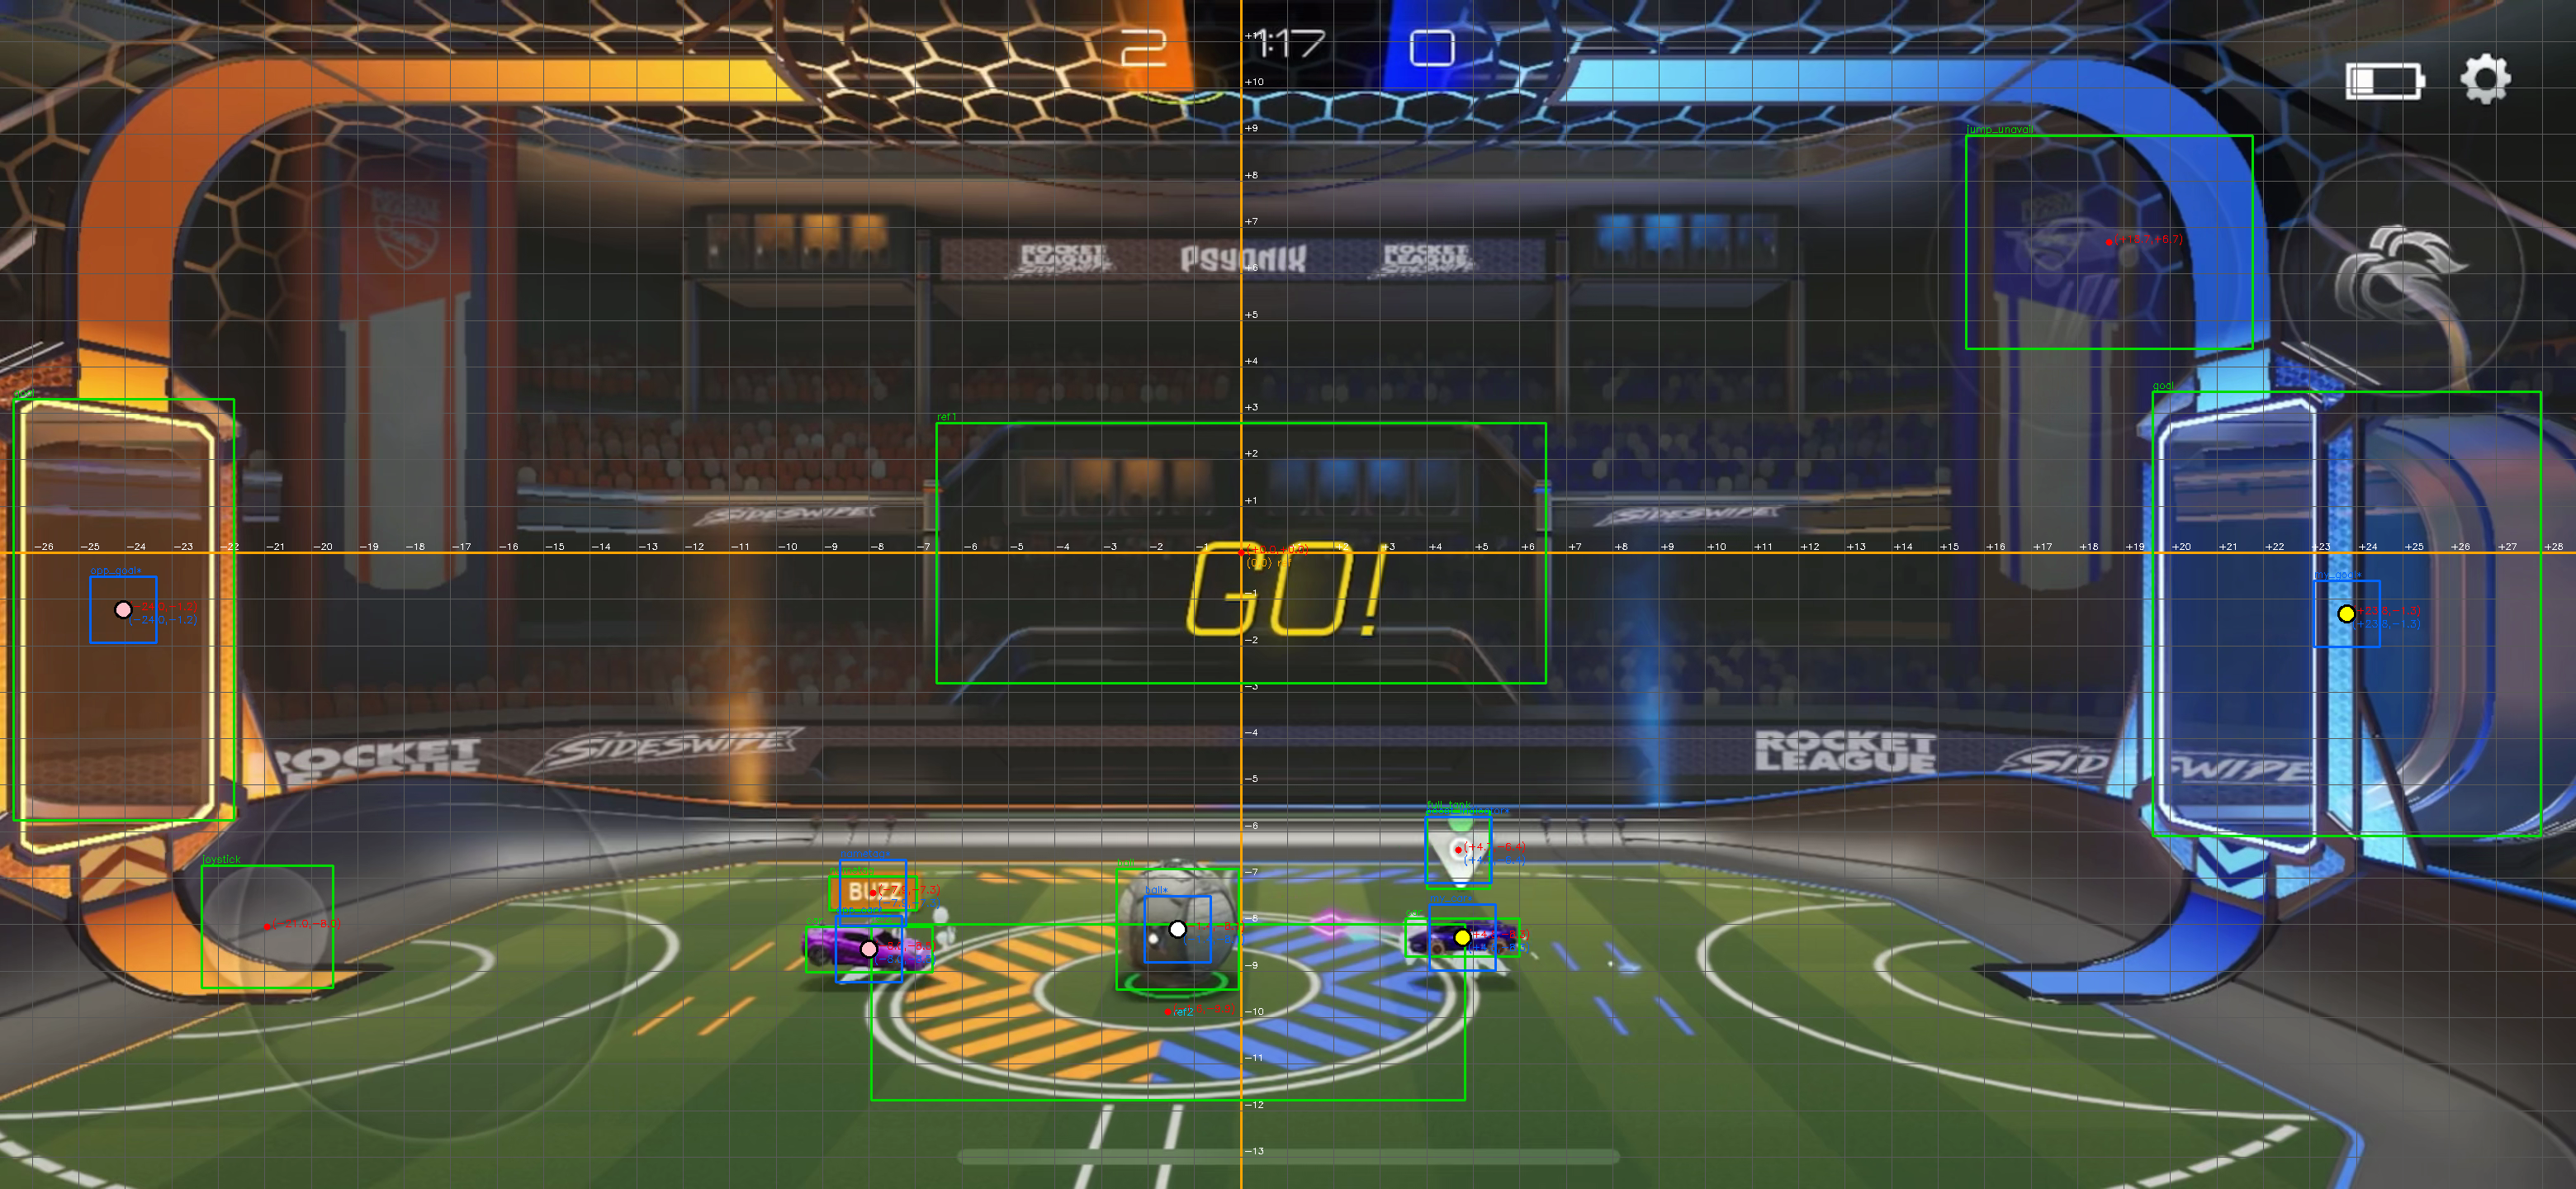

In [46]:
import math

def explain_action(action):
    """Decode the full action vector into human-readable terms."""
    print("\nACTION:")

    # --- joystick (first 3 elements: valid, sin, cos) ---
    joy_valid, sin_a, cos_a = action[0], action[1], action[2]
    if joy_valid >= 0.5:
        ang = math.degrees(math.atan2(sin_a, cos_a)) % 360
        # name the rough direction
        dirs = ["right", "up-right", "up", "up-left", "left",
                "down-left", "down", "down-right"]
        direction = dirs[int((ang + 22.5) % 360 // 45)]
        print(f"  joystick:  PUSHED   angle={ang:6.1f}deg ({direction})  "
              f"[sin={sin_a:+.3f}, cos={cos_a:+.3f}]")
    else:
        print(f"  joystick:  NEUTRAL (centered / not pushed)")

    # --- boosting (element 3) ---
    boosting = action[3]
    print(f"  boosting:  {'YES' if boosting >= 0.5 else 'no ':4s}  [{boosting:.1f}]")

    # --- jumped (element 4) ---
    jumped = action[4]
    print(f"  jumped:    {'YES' if jumped >= 0.5 else 'no ':4s}  [{jumped:.1f}]")

import json

# observation layout: 7 objects x 5 slots, then boost_level, jump_flag
OBS_OBJECTS = ["ball", "my_car", "opp_car", "nametag", "boost_indicator",
               "my_goal", "opp_goal"]
SLOT_LABELS = ["visible", "ux", "uy", "vx", "vy"]


def explain_frame(video_to_inspect, frame_num):
    with open(f"data{video_to_inspect}/data.jsonl", "r") as f:
        line = f.readlines()[frame_num]
    with open(f"data{video_to_inspect}/flags.txt", "r") as f:
        print(f.readlines()[frame_num])
    record = json.loads(line)
    obs = record["obs"]
    action = record["action"]

    print(f"=== frame {frame_num} ===\n")
    print("OBSERVATION:")
    idx = 0
    for obj in OBS_OBJECTS:
        slots = obs[idx:idx + 5]
        vis = slots[0]
        if vis >= 0.5:
            print(f"  {obj:16s} visible  "
                  f"pos=({slots[1]:+7.3f}, {slots[2]:+7.3f})  "
                  f"vel=({slots[3]:+7.3f}, {slots[4]:+7.3f})")
        else:
            print(f"  {obj:16s} NOT visible")
        idx += 5

    # trailing scalars
    boost_level = obs[idx]; idx += 1
    jump_flag = obs[idx]; idx += 1
    print(f"  {'boost_level':16s} {boost_level:.3f}  (0=empty, 1=full)")
    print(f"  {'jump_available':16s} {'YES' if jump_flag >= 0.5 else 'NO'}")

    explain_action(action)
    print(f"\nraw json:\n{line.strip()}")
    img_name = sorted(os.listdir(f"images/coordinatesystem{video_num}"))[frame_num]
    full_path = f"images/coordinatesystem{video_num}/{img_name}"
    print("PATH OF IMAGE: " + full_path)
    return Image.open(full_path)

video_num = "/0923-1"
# usage
explain_frame(video_num, 1)

In [42]:
import os
import json
from pathlib import Path

def process_video(video_num, model, units_per_span=10):
    """
    Full pipeline for one video:
      1. splice the video into frames_out{video_num}/
      2. build observation + action vectors per frame (with cleaning/velocity)
      3. draw the coordinate system for each frame -> images/coordinatesystem{video_num}/
      4. write data -> data/json{video_num}/data.jsonl  and flags -> flags.txt
    """
    # --- paths ---
    video_path  = f"training/videos{video_num}.mp4"
    frames_dir  = f"images/frames_out{video_num}"
    coord_dir   = f"images/coordinatesystem{video_num}"
    json_dir    = f"data{video_num}"

    os.makedirs(frames_dir, exist_ok=True)
    os.makedirs(coord_dir, exist_ok=True)
    os.makedirs(json_dir, exist_ok=True)

    # --- 1. splice (skips if frames already exist, per your splice_video) ---
    splice_video(video_path, frames_dir)
    frames = load_spliced_frames(frames_dir)
    print(f"{len(frames)} frames to process")

    # clear old coordinate-system images
    for file in Path(coord_dir).iterdir():
        if file.is_file():
            file.unlink()

    # --- 2 & 3. build vectors + draw coordinate system per frame ---
    records = []
    for i, (ts, path) in enumerate(frames):
        obs, action, flags, detections, cleaned, rgb, frame_number = build_vector(
            path, model, ts=ts, reset=(i == 0), return_debug=True
        )
        records.append({"obs": obs, "action": action, "flags": flags})
        draw_coord_system(
            rgb.copy(), detections, cleaned=cleaned,
            units_per_span=units_per_span, video=video_num + "/"
        )
        if (i + 1) % 50 == 0:
            print(f"  processed {i+1}/{len(frames)}")

    # --- 4. write data (numpy -> float, JSONL) and flags ---
    data = [{"obs": [float(x) for x in r["obs"]],
             "action": [float(x) for x in r["action"]]} for r in records]

    with open(f"{json_dir}/data.jsonl", "w", encoding="utf-8") as f:
        for item in data:
            f.write(json.dumps(item) + "\n")

    with open(f"{json_dir}/flags.txt", "w", encoding="utf-8") as f:
        for idx, r in enumerate(records):
            for flag in r["flags"]:
                f.write(f"FLAG: {flag},  ")
            f.write(f"For observation number: {idx} \n")

    print(f"done: {len(data)} records -> {json_dir}/data.jsonl  (+ flags.txt, coord images)")
    return records


# --- run it ---
records = process_video("/0923-1", model)

loaded 214 frames from images/frames_out/0923-1
214 frames to process
[frame 0] FLAG: missing boost indicator
Calculating joystick action...
names:  ['goal' 'ball' 'joystick' 'ref2' 'ref1' 'jump_avail' 'goal' 'car'
 'nametag' 'car' 'boost']
Found joystick at index 2
joystick angle: 3.107951504048721
saved images/coordinatesystem/0923-1/coords_2026-10-06_18-24-02-893.png
[frame 1] FLAG: missing boost indicator
Calculating joystick action...
names:  ['ref2' 'full_tank' 'goal' 'ref1' 'joystick' 'ball' 'car' 'goal' 'nametag'
 'car' 'jump_unavail']
Found joystick at index 4
joystick angle: 3.1028710976096896
saved images/coordinatesystem/0923-1/coords_2026-10-06_18-24-03-101.png
[frame 2] FLAG: missing jump indicator
[frame 2] FLAG: missing boost indicator
Calculating joystick action...
names:  ['joystick' 'goal' 'ball' 'ref1' 'ref2' 'full_tank' 'goal' 'nametag' 'car'
 'car']
Found joystick at index 0
joystick angle: 3.1052009602922643
saved images/coordinatesystem/0923-1/coords_2026-10-06_